In [1]:
# Experiment (Visualization) note on n-gram language modeling (notebook scale but with visualization)
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 16],  # 16 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)


# 1. load a small subset of the dataset (checked)
# 2. tokenize & build data loader (checked)
# 3. train with SoRL. 
# 4. visualize abstraciton dynamics (similar to copy-n-paste, but more generally on per-n-gram statistics)

In [2]:
from data.tinystory_local import TinyStoriesDataLoader, collect_rollout_statistics, AbstractionStatistics
from data.tinystory_local import visualize_dynamics
import tiktoken 

# TinyStories Dataset + GPT2 tokenizer
# -------------------------------------
num_stories = 100
max_len = 36
K = 4
loader = TinyStoriesDataLoader(num_stories=num_stories, max_len=max_len, chunk_size=K, device='cpu')

doc_len = max_len  + (max_len - 1) // K # <-- doc len contains abstract tokens
batch_size = 8
memory_span = 2 * max_len + 2
attn_blocksize = 1792
max_iterations = 2

# ---- stat collection ---
abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# --- tokenizer --- 
enc = tiktoken.get_encoding("gpt2")
eot = enc._special_tokens['<|endoftext|>']

Loading 100 stories from TinyStories train...
Loaded 100 stories, 3600 tokens total, 0.01 MB
Collected 726 unique 4-chunks


In [3]:
# train SoRL 

# Dynamic Visualization of SoRL
# 1. select-one SoRL
from sorl.neo_utils import sorl_rollout_v2, select_best_per_doc, select_best_per_doc_v2, sorl_evaluate_v2, compute_vocab_utilization_rate
from sorl.topo import orthogonalize_abs_param
from collections import defaultdict
from sorl.info import SoRLLoss, SoRLLoss_v2, SoRLLoss_v3, SoRLLoss_v4, SoRLLoss_v5

# --- orthogonal initialization on abs param --- 
orthogonalize_abs_param(model, do_wte=True, do_head=True)

loss_fn = SoRLLoss_v5(model.vocab_sizes[1], decay=0.8, target_vocab_util=0.9)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
n = 2
temperature = torch.tensor([0.0, 5.0], device=model.device)
num_steps = 400 
alpha_abs = 0.1
alpha_soft_zipf = 1.0
alpha_topo = 0.0
r_min = 1.0 
reward_mode = 1

record = defaultdict(list)
img_frames = []

for step in range(num_steps): 

    optimizer.zero_grad()

    tokens, doc_ids = loader.get_batch(batch_size)

    with torch.no_grad(): 
        # --- breakdown of SoRL search (select one per-document) ---
        search_data, search_ppt = sorl_rollout_v2(tokens, model, n=n, K=K, 
                                    max_iterations=max_iterations,
                                    memory_span=memory_span,
                                    attn_blocksize=attn_blocksize,
                                    temperature=temperature,
                                    truncate_seq_len=False)
        search_ppt = search_ppt.reshape(search_data.shape[0], -1)

        levels = (search_data >= model.vocab_sizes[0]).long()
        best_data, best_ppt, best_ppt_advantage, utility_reward = select_best_per_doc_v2(search_data, search_ppt, levels, r_min=r_min, reward_mode=reward_mode)

    # --- compute loss --- 
    traj_loss, abs_loss, zipf_bigram_loss, topo_loss = loss_fn(best_data, model, memory_span, attn_blocksize, utility_reward[1:])
    loss = traj_loss + alpha_abs * abs_loss + alpha_soft_zipf * zipf_bigram_loss + alpha_topo * topo_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, 10.0], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss, abs_logits, abs_tokens = sorl_evaluate_v2(tokens, model, n=2, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            _, _, zipf_bigram_loss, topo_loss = loss_fn(val_tokens, model, memory_span, attn_blocksize, torch.ones_like(val_tokens[..., 1:]))
            abs_stats.update(abs_logits, traj_loss, abs_tokens, doc_ids)
            record['vocab_util'].append(abs_stats.vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['traj_loss'].append(traj_loss.item())
            record['topo_loss'].append(topo_loss.item())
            record['bigram_rep_rate'].append(abs_stats.bigram_rep_rate)
            record['kl_soft_zipf'].append(zipf_bigram_loss.item())

        print(f"\nvalidation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {abs_stats.vocab_util * 100:.2f}%  | bigram-zipf kl: {zipf_bigram_loss.item():.2f} | topo similarity: {-topo_loss.item():.2f} | bigram rep rate: {abs_stats.bigram_rep_rate:.2f}")
        
        img = visualize_dynamics(abs_stats, loader, model, enc, K, step)
        img_frames.append(img)
        break


validation step 0 | traj_loss: 10.75 | abs_loss: 8.91 | search adv: 0.05% | vocab util: 87.50%  | bigram-zipf kl: 61.84 | topo similarity: 0.93 | bigram rep rate: 0.93


In [44]:
from sorl.forget import collect_forget_data, plot_normalized_correlation_lines, train_forget_vec
from tqdm import tqdm as tqdm

# ---- Memory Interference Experiment ---

# --- Load model, prepare abs stats record ---
model.load_state_dict(torch.load('sorl_tinystories.pt'))

abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

abs_stats_post = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# # ---- Compute 'Forget Matrix' --- 
# forget_mat = torch.zeros(num_stories, num_stories, device=model.device)
# num_steps = 40
# for train_idx in tqdm(range(num_stories)): 
#     forget_vec = train_fogret_vec(train_idx, loader, model, abs_stats, abs_stats_post, optimizer, num_steps,
#                                 max_iterations, memory_span, attn_blocksize, temperature, K, r_min, reward_mode, loss_fn, alpha_abs, alpha_soft_zipf, alpha_topo,
#                                 ckpt_path="sorl_tinystories.pt")
#     forget_mat[train_idx] = forget_vec 

# torch.save(forget_mat, "forget_mat.pt") # save it just in case

# # ---- Visualize 'Forget Matrix' --- 
# correlation_data, ham_corrs = collect_forget_data(forget_mat, abs_stats)

# plot_normalized_correlation_lines(
#     correlation_data, 
#     ham_corrs,
#     xlabel="Abstraction Edit Distance", 
#     ylabel="Forgetting (Δ Perplexity)",
#     title="Distant Abstractions → Less Forgetting (TinyStories)"
# )

In [ ]:
# Exp #1. 
# 'self-organization' of abstraction representation --> will SoRL tries to pull mixing memory apart? 
# Exp #2. 
# setting up tiny memory dataset training pipeline 
# Question #1. 
# What if we use all-rollout SoRL with utility advantage + KL reg terms? 


In [ ]:
# After training on 1 extra data point, abstract sequence that describes it changes.

abs_before = abs_stats.abs_seqs[0]
abs_after = abs_stats_post.abs_seqs[0]

print(f"Abs seq BEFORE: {abs_before.tolist()}")
print(f"Abs seq AFTER:  {abs_after.tolist()}")
print(f"Changed: {(abs_before != abs_after).any().item()}")

Abs seq BEFORE: [50261, 50267, 50258, 50270, 50258, 50269, 50260, 50258]
Abs seq AFTER:  [0, 0, 0, 0, 0, 0, 0, 0]
Changed: True


In [ ]:
from data.tinystory_local import *
from sklearn.decomposition import PCA

cs_sim = abs_stats.compute_cross_doc_logit_sim()
# cs_sim = abs_stats.compute_cross_doc_hamming()
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(cs_sim.cpu().numpy())

# Now use in 3D visualization
train_idx = 0
perplexity = forget_mat[train_idx]
img = visualize_forget_terrain(coords_2d, perplexity, trained_idx=train_idx, step=step)
# img = visualize_perplexity_terrain(coords_2d, perplexity, trained_idx=train_idx, step=step)

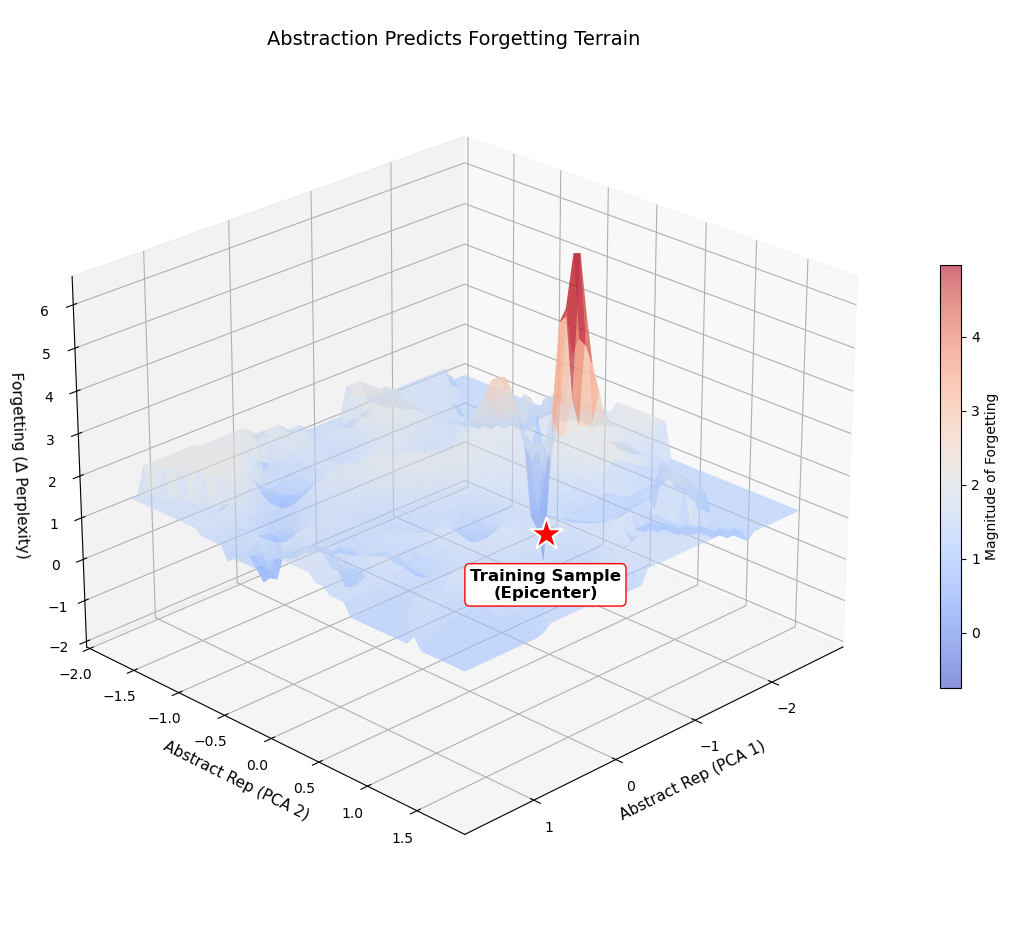

In [102]:
img


In [4]:
# Hypothesis #2. 
# ------------------------------------------------------------
# forget(i | j) is proportional to 1 / d(a_i, a_j)
# dis-similar concept is less likely to be overwritten by each other
# similar concept is more likely to be overwritten by each other
# the emerged abstraction system from SoRL can describe such similarity via d(a_i, a_j)
# ------------------------------------------------------------

# Experiment 
# (a). Train till emergence
# (b). Train with specific order. 
# (c). Record 'forgetting matrix'

import numpy as np
np.array(record['topo_loss'][:5]).mean(), np.array(record['topo_loss'][-5:]).mean()

(-0.7774280548095703, -0.7865824460983276)

In [4]:
if len(img_frames) > 0:
    img_frames[0].save(
        'tinystories_dynamics (select-best per abs SoRL + 1.0 topo reg + 1.0 bigram zipf reg + utility reward scaling.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

Saved GIF with 200 frames


In [ ]:
# Generate with SoRL trained on TinyStories Dataset
# -------------------------------------------------
from sorl.neo_utils import generate
from data.tinystory_local import visualize_interleaved_alignment    

min_temperature = 0.0
tokens, doc_ids = loader.get_batch(1)

idx = tokens[:, :15].clone()

img_frames = []
for i in range(30): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    img = visualize_interleaved_alignment(idx, model, enc, K=K, max_chunks=8)
    img_frames.append(img)

# ---- save to gif ----
if len(img_frames) > 0:
    img_frames[0].save(
        'tiny-tiny-stories-generation.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

In [ ]:
# Request #1. 
# -> Full scale experiment on TinyStories & FineWeb

In [ ]:
# marg cond w = 1.0 
# traj_loss: 0.85 | abs_loss: 0.04 | search adv: 21.01% | vocab util: 93.75%  | marg_ent: 2.67 | cond_ent: 0.05 | avg cos sim: 0.44

# soft bigram zipf kl w = 1.0 
# traj_loss: 0.89 | abs_loss: 0.53 | search adv: 25.84% | vocab util: 68.75%  | kl_soft_zipf: 0.24 | avg cos sim: 0.47
# -> visually I observe much less 'repetitions'

# soft bigram zipf kl w = 1.0 & utility reward scaling r = max(p(s|a)/p(s), 1.0)
# traj_loss: 0.79 | abs_loss: 0.40 | search adv: 30.13% | vocab util: 62.50%  | kl_soft_zipf: 0.17 | avg cos sim: 0.44 | topo sim: 0.77 

# soft bigram zip w=1.0 & utility reward scaling & topo reg w=1.0
# traj loss: 1.50 | search adv: 20% | avg cos sim: 0.24 | topo sim: 0.53
# => degrades utility, no go

